<a href="https://colab.research.google.com/github/MrChooey/Diabetes_Readmission/blob/main/models/Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Libraries

In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, auc
)
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

PATH_TO_TRAIN_CSV = "/content/drive/MyDrive/diabetes_readmission/Dataset/training.csv"
TARGET_COL = "readmitted"

df_train = pd.read_csv(PATH_TO_TRAIN_CSV)

print("Train shape:", df_train.shape)
print("Columns:", df_train.columns.tolist()[:10], "...")

print("\nTarget distribution:\n", df_train[TARGET_COL].value_counts(normalize=True).round(4))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Train shape: (71219, 105)
Columns: ['age', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'metformin'] ...

Target distribution:
 readmitted
0    0.8884
1    0.1116
Name: proportion, dtype: float64


In [ ]:
X = df_train.drop(columns=[TARGET_COL])
y = df_train[TARGET_COL].astype(int)

feature_names = X.columns.tolist()
print(f"X shape: {X.shape}, y shape: {y.shape}")

X shape: (71219, 104), y shape: (71219,)


# 5-Fold CV with SMOTE

In [ ]:
RANDOM_STATE = 42
N_SPLITS = 5

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

oof_pred = np.zeros(len(X), dtype=int)
oof_proba = np.zeros(len(X), dtype=float)

fold_metrics = []

# Tune later if needed
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

pipeline = Pipeline(steps=[
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("rf", rf),
])

print("Beginning 5-fold CV...")
for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), start=1):
    X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
    y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

    # Apply SMOTE to training folds
    pipeline.fit(X_tr, y_tr)

    # Don't apply SMOTE on validation folds
    va_proba = pipeline.predict_proba(X_va)[:, 1]
    va_pred = (va_proba >= 0.5).astype(int)

    oof_proba[va_idx] = va_proba
    oof_pred[va_idx] = va_pred

    fold_acc = accuracy_score(y_va, va_pred)
    fold_pre = precision_score(y_va, va_pred, zero_division=0)
    fold_rec = recall_score(y_va, va_pred, zero_division=0)
    fold_f1  = f1_score(y_va, va_pred, zero_division=0)
    fold_auc = roc_auc_score(y_va, va_proba)

    fold_metrics.append({
        "fold": fold,
        "accuracy": fold_acc,
        "precision": fold_pre,
        "recall": fold_rec,
        "f1": fold_f1,
        "auc_roc": fold_auc
    })

    print(f"Fold {fold}: "
          f"Acc={fold_acc:.4f} | Pre={fold_pre:.4f} | Rec={fold_rec:.4f} | F1={fold_f1:.4f} | AUC={fold_auc:.4f}")

print("\nDone.")

Beginning 5-fold CV...
Fold 1: Acc=0.8868 | Pre=0.3905 | Rec=0.0258 | F1=0.0484 | AUC=0.6281
Fold 2: Acc=0.8854 | Pre=0.3136 | Rec=0.0233 | F1=0.0434 | AUC=0.6391
Fold 3: Acc=0.8858 | Pre=0.3419 | Rec=0.0252 | F1=0.0469 | AUC=0.6173
Fold 4: Acc=0.8851 | Pre=0.3017 | Rec=0.0220 | F1=0.0410 | AUC=0.6294
Fold 5: Acc=0.8856 | Pre=0.3361 | Rec=0.0258 | F1=0.0479 | AUC=0.6160

Done.


# Average Performance

In [ ]:
metrics_df = pd.DataFrame(fold_metrics)
display(metrics_df)

avg_metrics = metrics_df[["accuracy", "precision", "recall", "f1", "auc_roc"]].mean()
std_metrics = metrics_df[["accuracy", "precision", "recall", "f1", "auc_roc"]].std()

print("\n=== Averaged 5-Fold Performance (Random Forest) ===")
for k in ["accuracy", "precision", "recall", "f1", "auc_roc"]:
    print(f"{k.upper():9s}: {avg_metrics[k]:.4f} ± {std_metrics[k]:.4f}")

,fold,accuracy,precision,recall,f1,auc_roc
0,1,0.886830,0.390476,0.025802,0.048406,0.628125
1,2,0.885355,0.313559,0.023285,0.043351,0.639070
2,3,0.885847,0.341880,0.025173,0.046893,0.617257
3,4,0.885145,0.301724,0.022013,0.041032,0.629421
4,5,0.885628,0.336066,0.025802,0.047925,0.615976



=== Averaged 5-Fold Performance (Random Forest) ===
ACCURACY : 0.8858 ± 0.0007
PRECISION: 0.3367 ± 0.0342
RECALL   : 0.0244 ± 0.0017
F1       : 0.0455 ± 0.0032
AUC_ROC  : 0.6260 ± 0.0095


# Build and save the level 1 OOF feature matrix

In [ ]:
level1_train = pd.DataFrame({
    "rf_oof_proba": oof_proba,
    "rf_oof_pred": oof_pred
}, index=X.index)

display(level1_train.head())

SAVE_PATH = "/content/drive/MyDrive/diabetes_readmission/Results/level1_oof_train_rf.csv"
level1_train.to_csv(SAVE_PATH, index=True)
print("Saved level-1 OOF matrix (RF) to:", SAVE_PATH)

,rf_oof_proba,rf_oof_pred
0,0.163333,0
1,0.320000,0
2,0.113333,0
3,0.263333,0
4,0.183333,0


Saved level-1 OOF matrix (RF) to: /content/drive/MyDrive/diabetes_readmission/Results/level1_oof_train_rf.csv


# Visualization

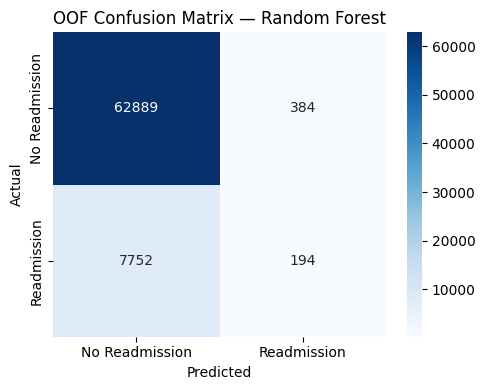

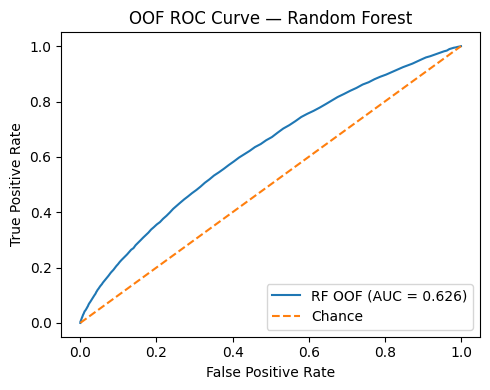

In [ ]:
# 1) Confusion Matrix (OOF)
cm = confusion_matrix(y, oof_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Readmission","Readmission"],
            yticklabels=["No Readmission","Readmission"])
plt.title("OOF Confusion Matrix — Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# 2) ROC Curve (OOF)
fpr, tpr, _ = roc_curve(y, oof_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f"RF OOF (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--", label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("OOF ROC Curve — Random Forest")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()